In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [13]:
url = "https://raw.githubusercontent.com/dD2405/Twitter_Sentiment_Analysis/master/train.csv"

df = pd.read_csv(url)

df.head()

,id,label,tweet
0,1,0,@user when a father is dysfunctional and is s...
1,2,0,@user @user thanks for #lyft credit i can't us...
2,3,0,bihday your majesty
3,4,0,#model i love u take with u all the time in ...
4,5,0,factsguide: society now #motivation


In [14]:
df.columns
df.shape
df.head()

,id,label,tweet
0,1,0,@user when a father is dysfunctional and is s...
1,2,0,@user @user thanks for #lyft credit i can't us...
2,3,0,bihday your majesty
3,4,0,#model i love u take with u all the time in ...
4,5,0,factsguide: society now #motivation


In [15]:
df['label'].value_counts()

,count
label,
0,29720
1,2242


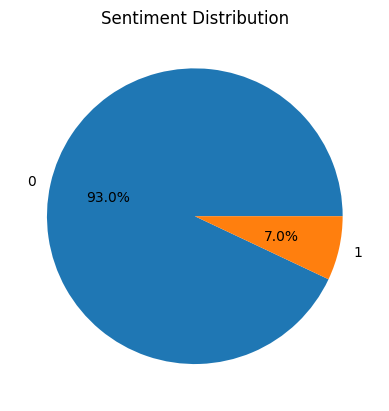

In [16]:
import matplotlib.pyplot as plt

df['label'].value_counts().plot(
    kind='pie',
    autopct='%1.1f%%'
)

plt.title("Sentiment Distribution")
plt.ylabel("")
plt.show()

In [17]:
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score

X = df['tweet']
y = df['label']

vectorizer = CountVectorizer()

X = vectorizer.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = MultinomialNB()

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.9425934615986234


In [18]:
sample_tweet = ["I am very happy today"]

sample_vector = vectorizer.transform(sample_tweet)

prediction = model.predict(sample_vector)

if prediction[0] == 0:
    print("Positive Sentiment 😊")
else:
    print("Negative Sentiment 😞")

Positive Sentiment 😊


In [19]:
tweets = [
    "I love this product",
    "This service is terrible",
    "Today is a normal day"
]

for tweet in tweets:
    pred = model.predict(vectorizer.transform([tweet]))
    sentiment = "Positive 😊" if pred[0] == 0 else "Negative 😞"
    print(tweet, "->", sentiment)

I love this product -> Positive 😊
This service is terrible -> Positive 😊
Today is a normal day -> Positive 😊
